# 2.6: Seaborn — Avanzado

FacetGrid, regresión visual, paletas personalizadas y combinación con Matplotlib.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', font_scale=1.1)
tips     = sns.load_dataset('tips')
penguins = sns.load_dataset('penguins')

## 4.1 FacetGrid — múltiples paneles por categoría

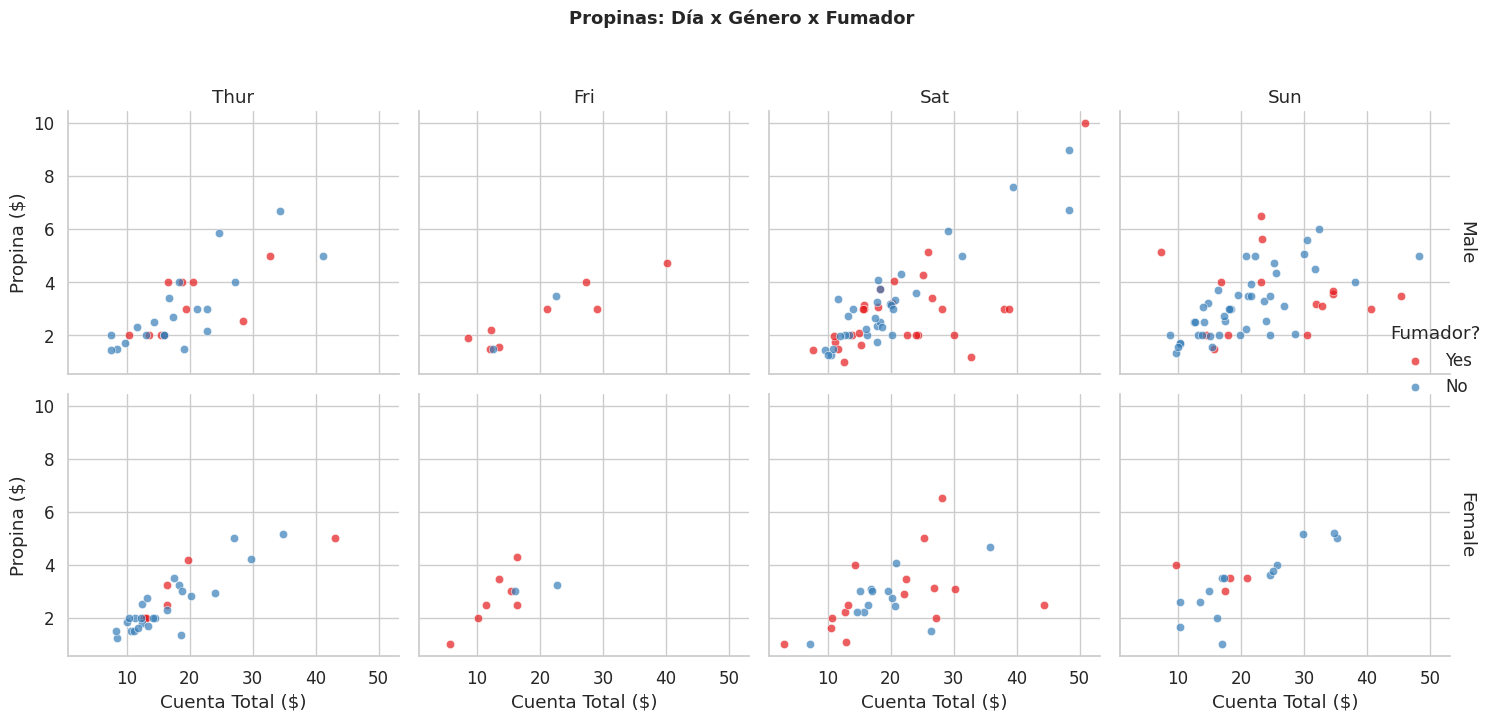

In [2]:
# FacetGrid crea una cuadrícula de subplots
# donde cada panel muestra los datos de una categoría específica

g = sns.FacetGrid(
    tips,
    col='day',           # variable para las COLUMNAS (un panel por valor único)
    row='sex',           # variable para las FILAS
    height=3.5,          # alto de cada panel en pulgadas
    aspect=1.0,          # ancho = height * aspect
    hue='smoker',        # color dentro de cada panel
    palette='Set1',
    margin_titles=True)  # títulos en los márgenes en lugar de dentro

# map() aplica una función de plot a CADA panel
# Primer argumento: función | Siguientes: columnas del DataFrame
g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.7)

g.add_legend(title='Fumador?')
g.set_axis_labels('Cuenta Total ($)', 'Propina ($)')
g.set_titles(col_template='{col_name}', row_template='{row_name}')

g.figure.suptitle('Propinas: Día x Género x Fumador', y=1.03, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 4.2 regplot y lmplot — regresión visual

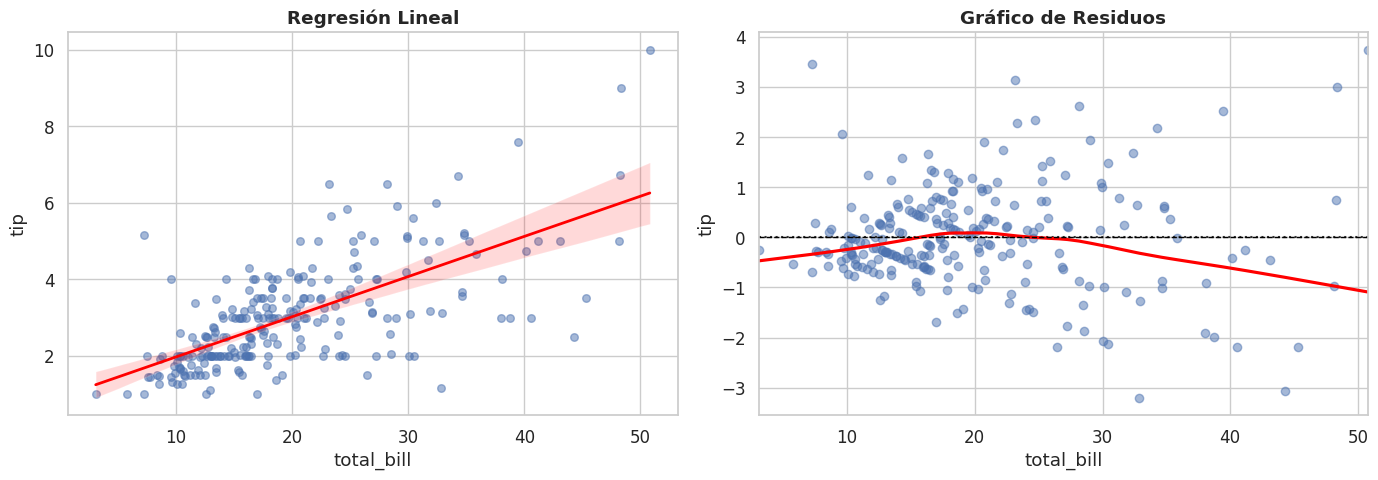

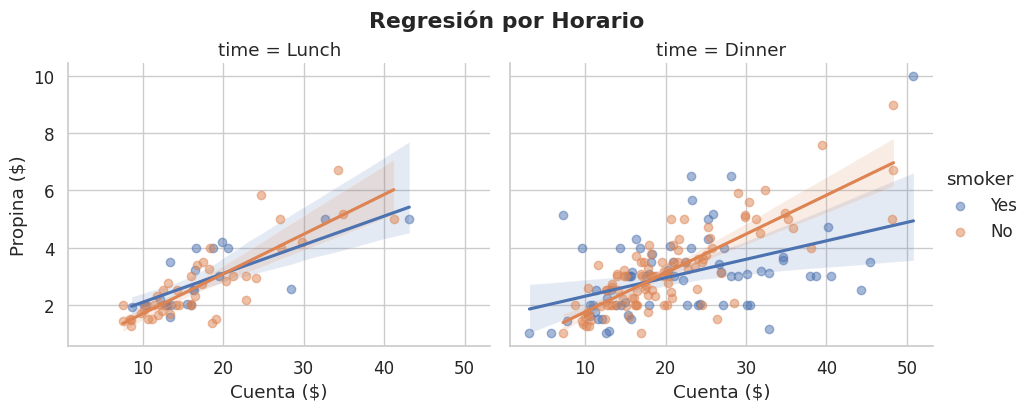

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# regplot — scatter + línea de regresión OLS + IC 95% automáticos
sns.regplot(
    data=tips, x='total_bill', y='tip',
    scatter_kws={'alpha':0.5, 's':30},        # kwargs para los puntos
    line_kws={'color':'red', 'linewidth':2},   # kwargs para la línea
    ci=95,    # nivel del intervalo de confianza (0-100). None=desactiva
    order=1,  # grado del polinomio: 1=lineal | 2=cuadrática
    ax=axes[0])
axes[0].set_title('Regresión Lineal', fontweight='bold')

# residplot — gráfico de residuos
# Residuo = valor real - valor predicho
# Buen modelo → residuos aleatorios alrededor de 0
sns.residplot(
    data=tips, x='total_bill', y='tip',
    lowess=True,  # True = añade curva LOWESS para detectar patrones
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'},
    ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Gráfico de Residuos', fontweight='bold')

plt.tight_layout()
plt.show()

# lmplot — como regplot pero con FacetGrid incorporado
# NO acepta parámetro ax=
g = sns.lmplot(
    data=tips, x='total_bill', y='tip',
    col='time',     # panel por horario
    hue='smoker',   # color por fumador
    ci=95, scatter_kws={'alpha':0.5},
    height=4, aspect=1.2)
g.set_axis_labels('Cuenta ($)', 'Propina ($)')
g.figure.suptitle('Regresión por Horario', y=1.03, fontweight='bold')
plt.show()

## 4.3 Paletas de colores

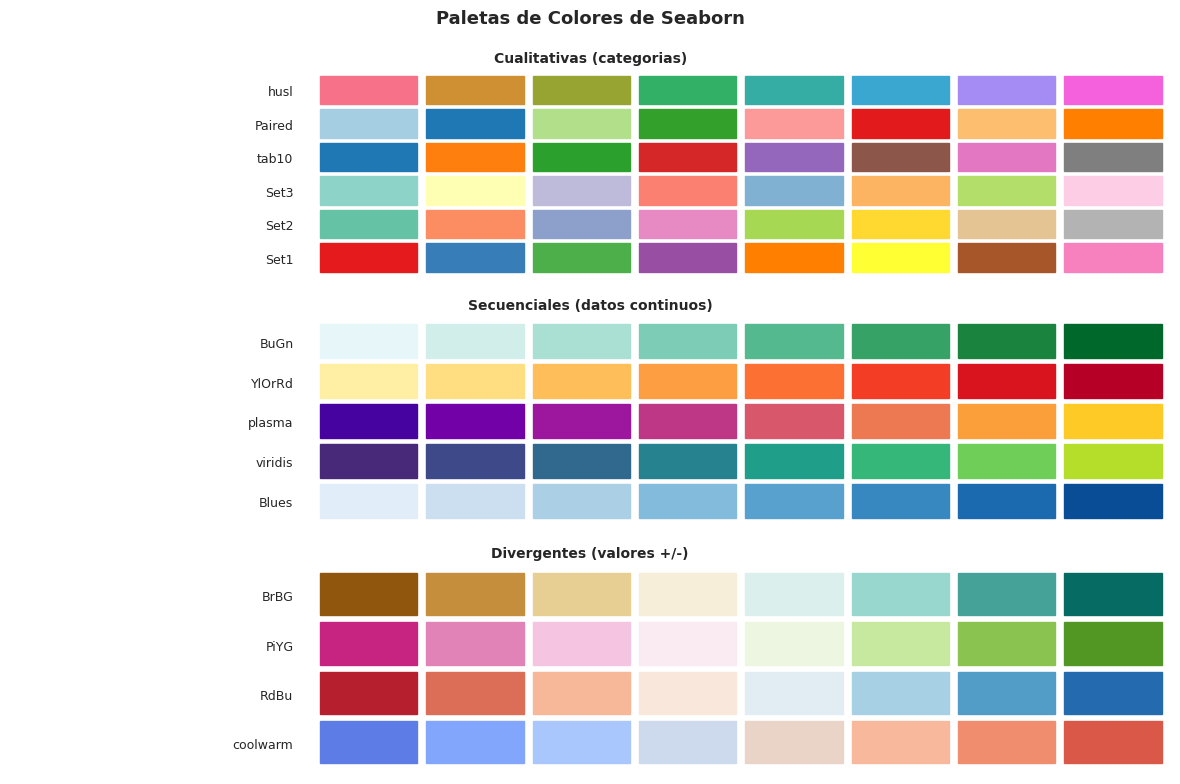

Paleta personalizada activada


In [4]:
paletas = {
    'Cualitativas (categorias)': ['Set1','Set2','Set3','tab10','Paired','husl'],
    'Secuenciales (datos continuos)': ['Blues','viridis','plasma','YlOrRd','BuGn'],
    'Divergentes (valores +/-)': ['coolwarm','RdBu','PiYG','BrBG']
}

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for ax, (tipo, lista) in zip(axes, paletas.items()):
    n_col = 8
    for i, nombre in enumerate(lista):
        colores = sns.color_palette(nombre, n_colors=n_col)
        # color_palette(nombre, n_colors) → lista de n colores
        # Cada color es una tupla RGB como (0.2, 0.5, 0.8)
        for j, color in enumerate(colores):
            ax.add_patch(plt.Rectangle((j*1.2, i*1.4), 1.1, 1.2, color=color))
        ax.text(-0.3, i*1.4+0.5, nombre, ha='right', va='center', fontsize=9)
    ax.set_xlim(-3.5, n_col*1.2)
    ax.set_ylim(-0.3, len(lista)*1.4)
    ax.set_title(tipo, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Paletas de Colores de Seaborn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Paleta personalizada
mi_paleta = sns.color_palette(['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6'])
sns.set_palette(mi_paleta)
# set_palette() → establece como predeterminada para todos los gráficos
print('Paleta personalizada activada')

## 4.4 Combinar Seaborn con Matplotlib

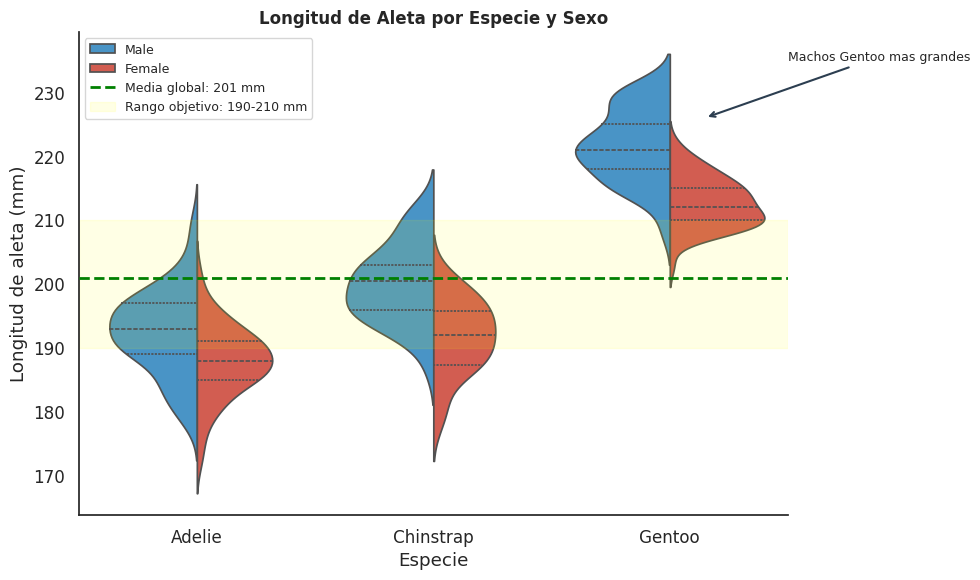

In [5]:
sns.set_theme(style='white', font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 6))

# PASO 1: Dibujar con Seaborn
sns.violinplot(
    data=penguins.dropna(),
    x='species', y='flipper_length_mm', hue='sex',
    split=True, inner='quart',
    palette={'Male':'#3498DB','Female':'#E74C3C'},
    ax=ax)

# PASO 2: Personalizar con Matplotlib
media_g = penguins['flipper_length_mm'].mean()
ax.axhline(media_g, color='green', linestyle='--', linewidth=2,
           label=f'Media global: {media_g:.0f} mm', zorder=5)

ax.axhspan(190, 210, alpha=0.1, color='yellow',
           label='Rango objetivo: 190-210 mm')
# axhspan(y_min, y_max) → banda horizontal semitransparente

ax.annotate('Machos Gentoo mas grandes',
            xy=(2.15, 226), xytext=(2.5, 235), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

ax.set_title('Longitud de Aleta por Especie y Sexo', fontsize=12, fontweight='bold')
ax.set_xlabel('Especie')
ax.set_ylabel('Longitud de aleta (mm)')

handles, labels = ax.get_legend_handles_labels()
# get_legend_handles_labels() → obtiene elementos actuales de la leyenda
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=9)

sns.despine(left=False, bottom=False)
# despine() → elimina bordes del gráfico
# Por defecto elimina borde superior y derecho

plt.tight_layout()
plt.show()